In [33]:
# ============================================================
# 1️⃣ IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

In [34]:
# ============================================================
# 2️⃣ LOAD & PREPROCESS MULTI-YEAR NSE DATASET
# ============================================================

df = pd.read_csv("NIFTY_5_Years.csv", encoding="utf-8-sig")

# Clean columns
df.columns = df.columns.str.strip()

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Sort ascending
df = df.sort_values("Date")

# Set index
df.set_index("Date", inplace=True)

# Use Close price
data = df[['Close']]

# Train-Test Split (80-20)
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

print("Training size:", len(train))
print("Testing size :", len(test))

Training size: 992
Testing size : 248


In [35]:
# ============================================================
# 3️⃣ SCALING FOR DEEP LEARNING
# ============================================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [36]:
# ============================================================
# 4️⃣ HELPER FUNCTIONS
# ============================================================

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)


def evaluate_model(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return rmse, mae, r2


time_steps = 60

In [37]:
# ==============================
# ARIMA + LSTM (Safe + Corrected)
# ==============================

time_steps = 20

# --- ARIMA ---
arima_model = ARIMA(train['Close'], order=(3,1,1))
arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))

# --- Residuals ---
residuals = test['Close'].values - arima_forecast.values
residuals = residuals.reshape(-1,1)

# Check if enough data
if len(residuals) <= time_steps:
    print("Not enough test data for LSTM residual modeling.")
    
    # Avoid NameError later
    rmse1, mae1, r21 = None, None, None

else:
    # --- Scale residuals ---
    res_scaler = MinMaxScaler()
    res_scaled = res_scaler.fit_transform(residuals)

    # --- Create sequences ---
    X_res, y_res = create_sequences(res_scaled, time_steps)

    print("Residual sequence shape:", X_res.shape)

    # --- LSTM Model ---
    model1 = Sequential()
    model1.add(LSTM(64, activation='relu', input_shape=(time_steps,1)))
    model1.add(Dense(1))

    model1.compile(optimizer='adam', loss='mse')

    model1.fit(X_res, y_res, epochs=30, batch_size=32, verbose=0)

    # --- Predict residuals ---
    lstm_res_pred = model1.predict(X_res)
    lstm_res_pred = res_scaler.inverse_transform(lstm_res_pred)

    # --- Final hybrid prediction ---
    final_arima_lstm = arima_forecast[time_steps:].values + lstm_res_pred.flatten()

    actual1 = test['Close'].values[time_steps:]

    # --- Store metrics correctly ---
    rmse1, mae1, r21 = evaluate_model(actual1, final_arima_lstm, "ARIMA + LSTM")

Residual sequence shape: (228, 20, 1)
8/8 [==============================] - 0s 3ms/step

ARIMA + LSTM
RMSE: 302.24683273928065
MAE : 233.72556719440664
R2  : 0.8457779194407818


## for arima Tuning tune (p,d,q) 
change order=(3,1,1) to like (1,1,1) or (2,1,2)or (5,1,0) or (5,1,2) or (7,1,3)
then compare using print(arima_result.aic) and print(arima_result.bic) Pick the order with lowest AIC/BIC.

## for LSTM tuning above : 
model1 = Sequential()
model1.add(LSTM(128, return_sequences=True, input_shape=(time_steps,1)))
model1.add(Dropout(0.2))
model1.add(LSTM(64))
model1.add(Dropout(0.2))
model1.add(Dense(1)) 

activation tanh 
different batch size
instead of MinMaxScaler() use StandardScaler()

In [38]:
# ============================================================
# SARIMA + LSTM
# ============================================================

sarima_model = SARIMAX(train['Close'],
                       order=(2,1,2),
                       seasonal_order=(1,1,1,12))
sarima_result = sarima_model.fit()

sarima_forecast = sarima_result.forecast(steps=len(test))

residuals_s = test['Close'].values - sarima_forecast.values
residuals_s = residuals_s.reshape(-1,1)

res_scaler_s = MinMaxScaler()
res_scaled_s = res_scaler_s.fit_transform(residuals_s)

X_res_s, y_res_s = create_sequences(res_scaled_s, time_steps)

model2 = Sequential([
    LSTM(64, activation='relu', input_shape=(time_steps,1)),
    Dense(1)
])

model2.compile(optimizer='adam', loss='mse')
model2.fit(X_res_s, y_res_s, epochs=30, batch_size=32, verbose=0)

lstm_res_pred_s = model2.predict(X_res_s)
lstm_res_pred_s = res_scaler_s.inverse_transform(lstm_res_pred_s)

final_sarima_lstm = sarima_forecast[time_steps:].values + lstm_res_pred_s.flatten()
actual2 = test['Close'].values[time_steps:]

rmse2, mae2, r22 = evaluate_model(actual2, final_sarima_lstm, "SARIMA + LSTM")

8/8 [==============================] - 0s 3ms/step

SARIMA + LSTM
RMSE: 253.59831265215337
MAE : 193.52001191954471
R2  : 0.8914285195454862


## For Sarima + LSTM Tuning : 
seasinal peroid change : seasonal_order=(1,1,1,5)     # Weekly trading cycle
seasonal_order=(1,1,1,21)    # Monthly trading cycle
seasonal_order=(0,1,1,5)
seasonal_order=(1,0,1,5)

tune (p,d,q) : (1,1,1)
(2,1,2)
(3,1,1)
(5,1,2)

after fitting : print("AIC:", sarima_result.aic)
print("BIC:", sarima_result.bic) choose lowset aic bic

LSTM(64, activation='relu')
epochs=30

increase time steps : time_steps = 20

better LSTM architecture : model2 = Sequential()
model2.add(LSTM(128, return_sequences=True, input_shape=(time_steps,1)))
model2.add(Dropout(0.2))
model2.add(LSTM(64))
model2.add(Dropout(0.2))
model2.add(Dense(1))

activation tanh

StandardScaler() instead of MinMaxScaler()



In [39]:
# ============================================================
# RNN + LSTM
# ============================================================

X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

model3 = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(time_steps,1)),
    LSTM(64),
    Dense(1)
])

model3.compile(optimizer='adam', loss='mse')
model3.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

rnn_lstm_pred = model3.predict(X_test)
rnn_lstm_pred = scaler.inverse_transform(rnn_lstm_pred)
actual3 = scaler.inverse_transform(y_test)

rmse3, mae3, r23 = evaluate_model(actual3, rnn_lstm_pred, "RNN + LSTM")

8/8 [==============================] - 0s 3ms/step

RNN + LSTM
RMSE: 251.52244415081947
MAE : 196.15772341008758
R2  : 0.8931987022572055


## RNN + LSTM Tuning
Increase Model Capacity : model3 = Sequential()

model3.add(SimpleRNN(128, return_sequences=True, input_shape=(time_steps,1)))
model3.add(Dropout(0.2))

model3.add(LSTM(128, return_sequences=True))
model3.add(Dropout(0.2))

model3.add(LSTM(64))
model3.add(Dropout(0.2))

model3.add(Dense(1))

INcrease time Steps : time_steps = 20 tp 30 60 or 90

activation tanh different batch size instead of MinMaxScaler() use StandardScaler()

In [40]:
# ============================================================
# SARIMA + RNN
# ============================================================

residuals2 = test['Close'].values - sarima_forecast.values
residuals2 = residuals2.reshape(-1,1)

res_scaler2 = MinMaxScaler()
res_scaled2 = res_scaler2.fit_transform(residuals2)

X_res2, y_res2 = create_sequences(res_scaled2, time_steps)

model4 = Sequential([
    SimpleRNN(64, input_shape=(time_steps,1)),
    Dense(1)
])

model4.compile(optimizer='adam', loss='mse')
model4.fit(X_res2, y_res2, epochs=30, batch_size=32, verbose=0)

rnn_res_pred = model4.predict(X_res2)
rnn_res_pred = res_scaler2.inverse_transform(rnn_res_pred)

final_sarima_rnn = sarima_forecast[time_steps:].values + rnn_res_pred.flatten()
actual4 = test['Close'].values[time_steps:]

rmse4, mae4, r24 = evaluate_model(actual4, final_sarima_rnn, "SARIMA + RNN")

8/8 [==============================] - 0s 2ms/step

SARIMA + RNN
RMSE: 217.85827815648992
MAE : 166.192655274686
R2  : 0.9198744221926711


## FOr SARIMA + RNN Tuning : 
seasonal_order=(1,1,1,5)   # Weekly trading cycle try seasonal_order=(1,1,1,5)   # Weekly trading cycle

print("AIC:", sarima_result.aic)
print("BIC:", sarima_result.bic) LOwer is better

Increase RNN Depth : model4 = Sequential()

model4.add(SimpleRNN(128, return_sequences=True, input_shape=(time_steps,1)))
model4.add(Dropout(0.2))

model4.add(SimpleRNN(64))
model4.add(Dropout(0.2))

model4.add(Dense(1))


tune time steps : time_steps = 20 to 30 or 60 or 90

tune optimizer : from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

model4.compile(optimizer=optimizer, loss='mse')

change loss function : loss='huber'

standardSclaer insted of MinMaxScaler()



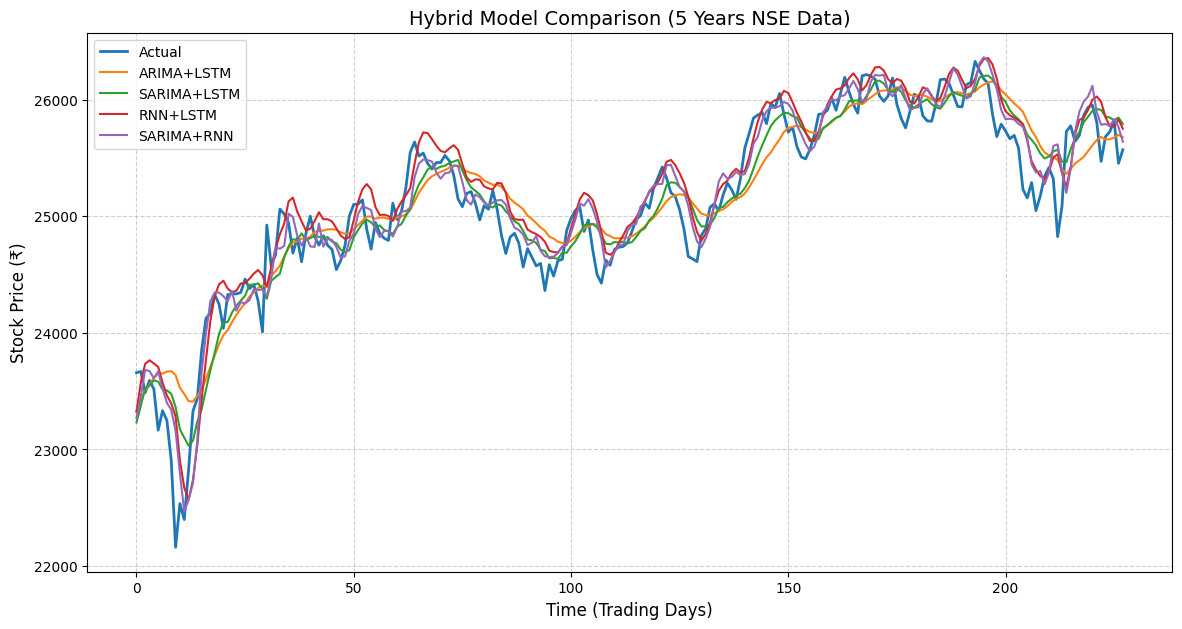

In [41]:
plt.figure(figsize=(14,7))

plt.plot(actual1, label="Actual", linewidth=2)
plt.plot(final_arima_lstm, label="ARIMA+LSTM")
plt.plot(final_sarima_lstm, label="SARIMA+LSTM")
plt.plot(rnn_lstm_pred, label="RNN+LSTM")
plt.plot(final_sarima_rnn, label="SARIMA+RNN")

# Axis Labels
plt.xlabel("Time (Trading Days)", fontsize=12)
plt.ylabel("Stock Price (₹)", fontsize=12)

# Title
plt.title("Hybrid Model Comparison (5 Years NSE Data)", fontsize=14)

# Legend
plt.legend()

# Grid (makes it look professional)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

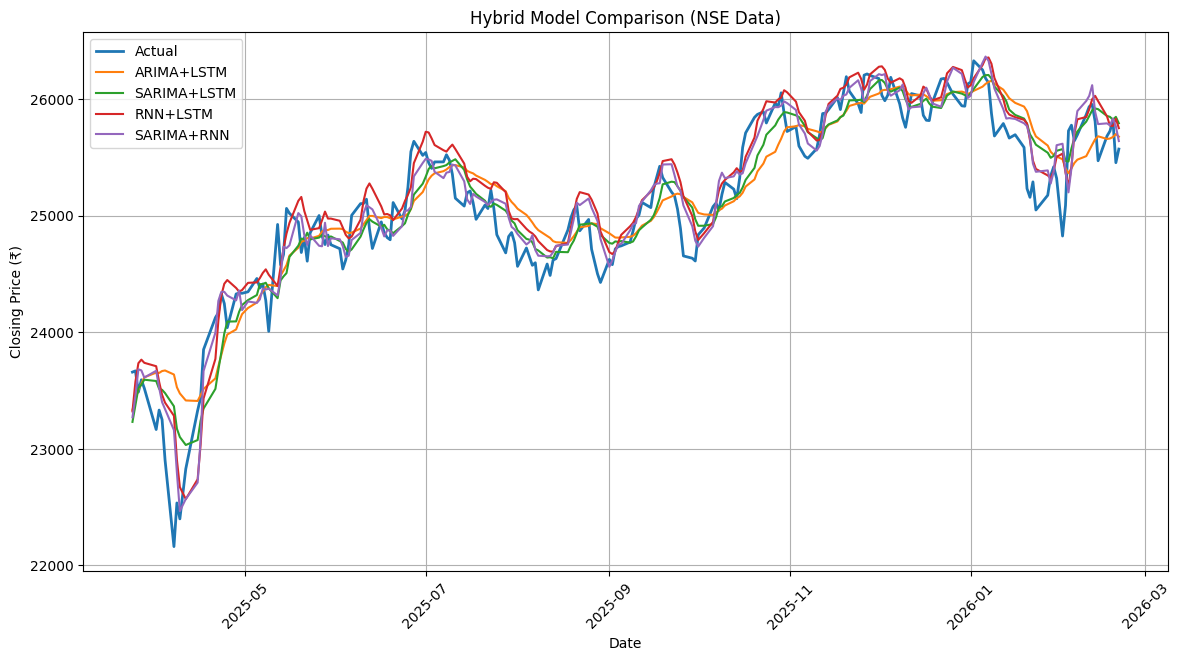

In [42]:
dates = test.index[time_steps:]

plt.figure(figsize=(14,7))

plt.plot(dates, actual1, label="Actual", linewidth=2)
plt.plot(dates, final_arima_lstm, label="ARIMA+LSTM")
plt.plot(dates, final_sarima_lstm, label="SARIMA+LSTM")
plt.plot(dates, rnn_lstm_pred, label="RNN+LSTM")
plt.plot(dates, final_sarima_rnn, label="SARIMA+RNN")

plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")
plt.title("Hybrid Model Comparison (NSE Data)")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [43]:
def evaluate_model_advanced(actual, predicted, model_name):
    
    actual = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    
    # Errors
    errors = actual - predicted
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs(errors / actual)) * 100
    
    # Volatility (returns std deviation)
    returns_actual = np.diff(actual) / actual[:-1]
    returns_pred = np.diff(predicted) / predicted[:-1]
    
    volatility_actual = np.std(returns_actual)
    volatility_pred = np.std(returns_pred)

    # Convert to direction (1 = Up, 0 = Down)
    actual_direction = np.where(np.diff(actual) > 0, 1, 0)
    pred_direction = np.where(np.diff(predicted) > 0, 1, 0)
    
    accuracy = accuracy_score(actual_direction, pred_direction)
    precision = precision_score(actual_direction, pred_direction)
    recall = recall_score(actual_direction, pred_direction)
    f1 = f1_score(actual_direction, pred_direction)
    
    cm = confusion_matrix(actual_direction, pred_direction)
    
    print(f"\n===== {model_name} =====")
    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("R2   :", r2)
    print("MAPE :", mape)
    print("Actual Volatility :", volatility_actual)
    print("Predicted Volatility :", volatility_pred)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("Confusion Matrix:\n", cm)
    
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape,
        "Actual_Volatility": volatility_actual,
        "Predicted_Volatility": volatility_pred,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    }, errors

In [44]:
metrics1, errors1 = evaluate_model_advanced(actual1, final_arima_lstm, "ARIMA + LSTM")
metrics2, errors2 = evaluate_model_advanced(actual2, final_sarima_lstm, "SARIMA + LSTM")
metrics3, errors3 = evaluate_model_advanced(actual3, rnn_lstm_pred, "RNN + LSTM")
metrics4, errors4 = evaluate_model_advanced(actual4, final_sarima_rnn, "SARIMA + RNN")


===== ARIMA + LSTM =====
RMSE : 302.24683273928065
MAE  : 233.72556719440664
R2   : 0.8457779194407818
MAPE : 0.9412813224692183
Actual Volatility : 0.007429352291041707
Predicted Volatility : 0.0015089423822419485
Accuracy : 0.4977973568281938
Precision: 0.5177304964539007
Recall   : 0.6134453781512605
F1 Score : 0.5615384615384615
Confusion Matrix:
 [[40 68]
 [46 73]]

===== SARIMA + LSTM =====
RMSE : 253.59831265215337
MAE  : 193.52001191954471
R2   : 0.8914285195454862
MAPE : 0.7786242391118445
Actual Volatility : 0.007429352291041707
Predicted Volatility : 0.002419630748691442
Accuracy : 0.5330396475770925
Precision: 0.5511811023622047
Recall   : 0.5882352941176471
F1 Score : 0.5691056910569106
Confusion Matrix:
 [[51 57]
 [49 70]]

===== RNN + LSTM =====
RMSE : 251.52244415081947
MAE  : 196.15772341008758
R2   : 0.8931987022572055
MAPE : 0.7892873903498391
Actual Volatility : 0.0074293522910417135
Predicted Volatility : 0.0041371
Accuracy : 0.5550660792951542
Precision: 0.576271

In [45]:
results_df = pd.DataFrame([metrics1, metrics2, metrics3, metrics4])

print("\n===== Final Model Comparison =====")
print(results_df)

# Sort by RMSE (best first)
results_df = results_df.sort_values("RMSE")
print("\nBest Model Based on RMSE:")
print(results_df.iloc[0])


===== Final Model Comparison =====
           Model        RMSE         MAE        R2      MAPE  \
0   ARIMA + LSTM  302.246833  233.725567  0.845778  0.941281   
1  SARIMA + LSTM  253.598313  193.520012  0.891429  0.778624   
2     RNN + LSTM  251.522444  196.157723  0.893199  0.789287   
3   SARIMA + RNN  217.858278  166.192655  0.919874  0.667085   

   Actual_Volatility  Predicted_Volatility  Accuracy  Precision    Recall  \
0           0.007429              0.001509  0.497797   0.517730  0.613445   
1           0.007429              0.002420  0.533040   0.551181  0.588235   
2           0.007429              0.004137  0.555066   0.576271  0.571429   
3           0.007429              0.004835  0.594714   0.609756  0.630252   

   F1_Score  
0  0.561538  
1  0.569106  
2  0.573840  
3  0.619835  

Best Model Based on RMSE:
Model                   SARIMA + RNN
RMSE                      217.858278
MAE                       166.192655
R2                          0.919874
MAPE        

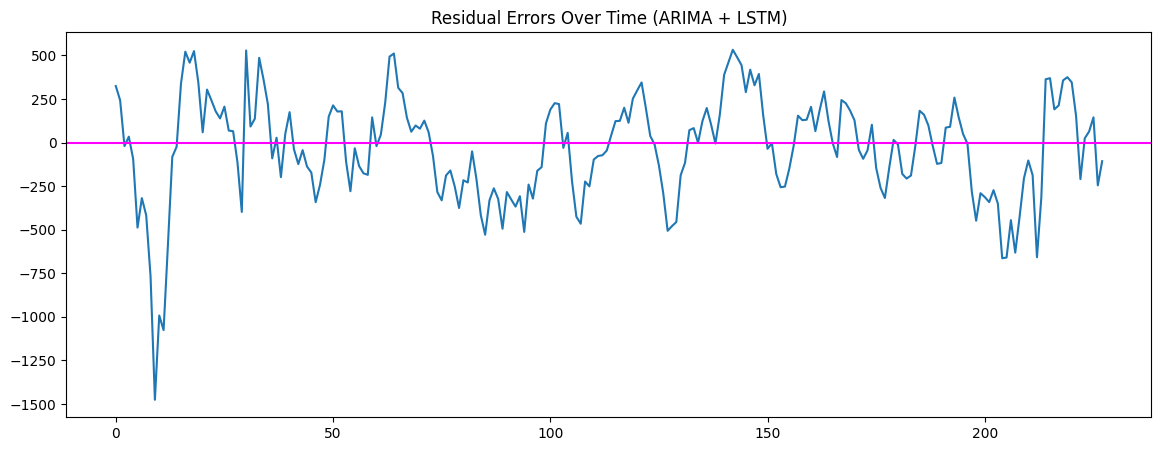

In [46]:
plt.figure(figsize=(14,5))
plt.plot(errors1)
plt.title("Residual Errors Over Time (ARIMA + LSTM)")
plt.axhline(0, color='magenta')
plt.show()

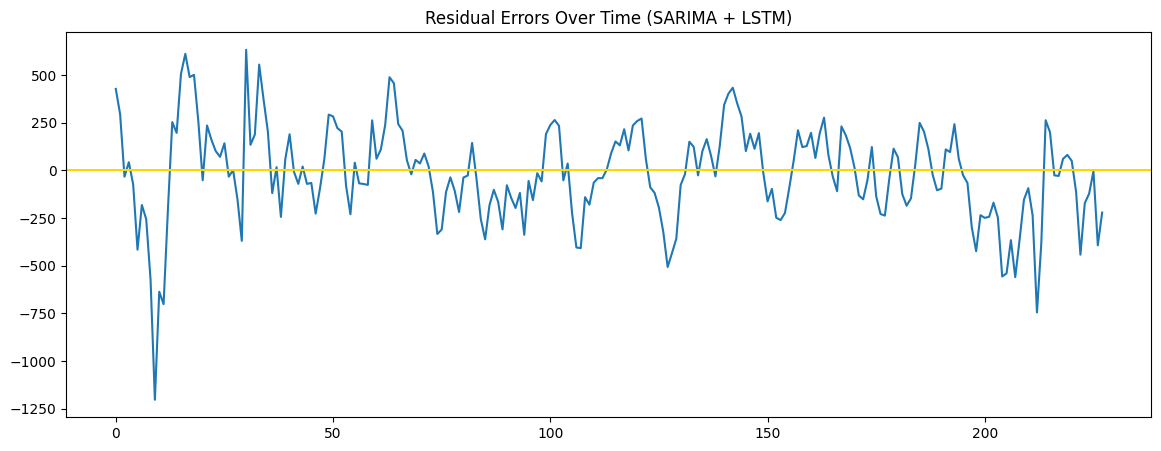

In [47]:
plt.figure(figsize=(14,5))
plt.plot(errors2)
plt.title("Residual Errors Over Time (SARIMA + LSTM)")
plt.axhline(0, color='gold')
plt.show()

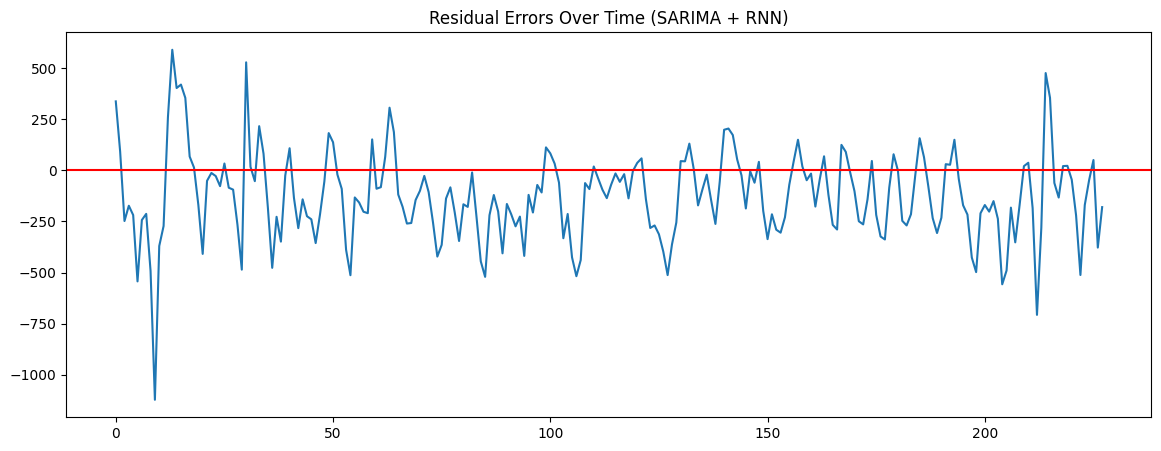

In [48]:
plt.figure(figsize=(14,5))
plt.plot(errors3)
plt.title("Residual Errors Over Time (SARIMA + RNN)")
plt.axhline(0, color='red')
plt.show()

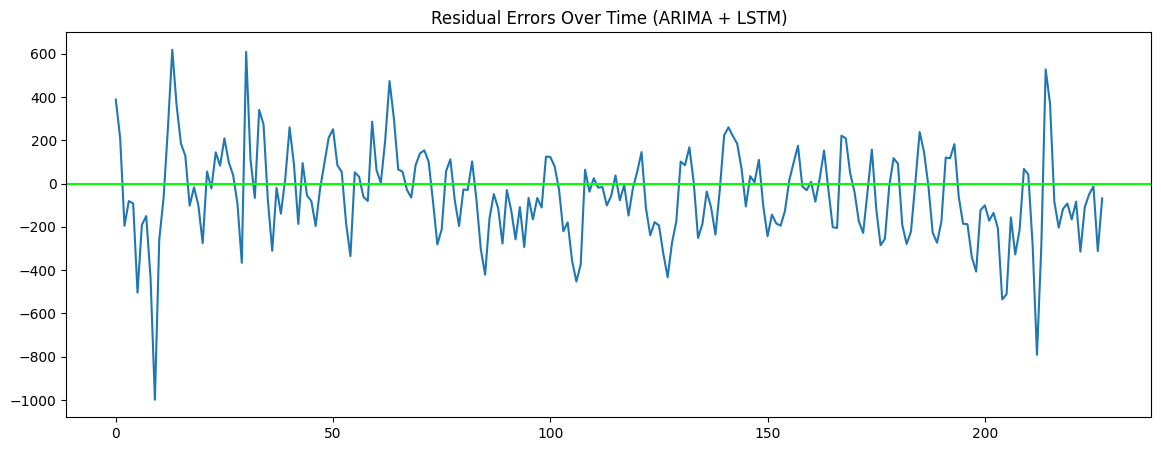

In [49]:
plt.figure(figsize=(14,5))
plt.plot(errors4)
plt.title("Residual Errors Over Time (ARIMA + LSTM)")
plt.axhline(0, color='lime')
plt.show()

In [50]:
prediction_df = pd.DataFrame({
    "Actual": actual1,
    "Predicted_ARIMA_LSTM": final_arima_lstm
})

print(prediction_df.head())

     Actual  Predicted_ARIMA_LSTM
0  23658.35          23333.923189
1  23668.65          23426.205405
2  23486.85          23506.943333
3  23591.95          23558.182253
4  23519.35          23613.621981


In [51]:
prediction_df = pd.DataFrame({
    "Actual": actual2,
    "Predicted_SARIMA_LSTM": final_sarima_lstm
})

print(prediction_df.head())

     Actual  Predicted_SARIMA_LSTM
0  23658.35           23231.061650
1  23668.65           23375.058936
2  23486.85           23520.204720
3  23591.95           23549.414200
4  23519.35           23592.894676


In [52]:
prediction_df = pd.DataFrame({
    "Actual": actual3.flatten(),
    "Predicted_RNN_LSTM": rnn_lstm_pred.flatten()
})

print(prediction_df.head())

     Actual  Predicted_RNN_LSTM
0  23658.35        23320.962891
1  23668.65        23576.230469
2  23486.85        23734.623047
3  23591.95        23764.941406
4  23519.35        23737.759766


In [53]:
prediction_df = pd.DataFrame({
    "Actual": actual4,
    "Predicted_SARIMA_RNN": final_sarima_rnn
})

print(prediction_df.head())

     Actual  Predicted_SARIMA_RNN
0  23658.35          23270.228916
1  23668.65          23457.116889
2  23486.85          23681.992135
3  23591.95          23672.949799
4  23519.35          23611.315025


In [54]:
import numpy as np

def predict_future_prices(model, last_data, scaler, time_steps, future_days):
    
    # Ensure correct shape
    input_seq = last_data[-time_steps:]
    input_seq = input_seq.reshape(1, time_steps, 1)

    future_predictions = []

    for _ in range(future_days):
        
        pred = model.predict(input_seq, verbose=0)
        
        # Store prediction
        future_predictions.append(pred[0, 0])
        
        # Reshape prediction properly to (1,1,1)
        pred_reshaped = pred.reshape(1, 1, 1)
        
        # Remove first timestep and append prediction
        input_seq = np.concatenate(
            (input_seq[:, 1:, :], pred_reshaped),
            axis=1
        )

    # Convert back to original scale
    future_predictions = scaler.inverse_transform(
        np.array(future_predictions).reshape(-1, 1)
    )

    return future_predictions.flatten()

In [55]:
future_days = 10

future_prices = predict_future_prices(
    model3,
    test_scaled,
    scaler,
    time_steps,
    future_days
)

print("Future Prices:", future_prices)

Future Prices: [25722.014 25732.377 25807.088 25868.582 25949.547 26019.008 26090.43
 26158.951 26211.51  26270.479]


In [56]:
last_date = df.index[-1]
future_dates = pd.date_range(last_date, periods=future_days+1)[1:]

future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Price": future_prices
})

print(future_df)

        Date  Predicted_Price
0 2026-02-21     25722.013672
1 2026-02-22     25732.376953
2 2026-02-23     25807.087891
3 2026-02-24     25868.582031
4 2026-02-25     25949.546875
5 2026-02-26     26019.007812
6 2026-02-27     26090.429688
7 2026-02-28     26158.951172
8 2026-03-01     26211.509766
9 2026-03-02     26270.478516
